# Merged from Phase3_Part1.ipynb

<a href="https://colab.research.google.com/github/Nikelroid/DeepLearning_Project/blob/main/Phase-3/Phase3_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading data onto the disk

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd drive/My Drive

/content/drive/My Drive


In [ ]:
# !ls drive/My\ Drive/

In [ ]:
# !cp train_ende.zip .
# !cp test.zip .

In [ ]:
#!git clone https://github.com/XL2248/MSCTD

In [ ]:
'''
!cp MSCTD/MSCTD_data/ende/english_*.txt .
!cp MSCTD/MSCTD_data/ende/image_index_*.txt .
!cp MSCTD/MSCTD_data/ende/sentiment_*.txt .

import os
import shutil

for file in os.listdir('MSCTD/MSCTD_data/ende'):
    if file.startswith('english_'):
        shutil.copy('MSCTD/MSCTD_data/ende/' + file, file)
    if file.startswith('image_index_'):
        shutil.copy('MSCTD/MSCTD_data/ende/' + file, file)
    if file.startswith('sentiment_'):
        shutil.copy('MSCTD/MSCTD_data/ende/' + file, file)
'''

In [ ]:
#!pip install --upgrade --no-cache-dir gdown
#!gdown --id 1GAZgPpTUBSfhne-Tp0GDkvSHuq6EMMbj
#!gdown --id 1B9ZFmSTqfTMaqJ15nQDrRNLqBvo-B39W

In [ ]:
%cd drive/MyDrive/dataset/train

In [ ]:
!ls

In [ ]:
!unzip train_ende.zip


In [ ]:
'''
%%bash
for x in *.zip
do
  unzip -qq $x
done
'''

In [ ]:
# !mkdir dataset
# !cd dataset; mkdir train test dev
'''
os.makedirs('dataset', exist_ok=True)
os.makedirs('dataset/train', exist_ok=True)
os.makedirs('dataset/test', exist_ok=True)
os.makedirs('dataset/dev', exist_ok=True)
'''

In [ ]:
# !mv *train* dataset/train
# !mv *test* dataset/test
# !mv *dev* dataset/dev
'''
for file in os.listdir():
    if 'train' in file:
        shutil.move(file, 'dataset/train')
    if 'test' in file:
        shutil.move(file, 'dataset/test')
    if 'dev' in file:
        shutil.move(file, 'dataset/dev')
'''

# Dataset and Dataloader

In [10]:
!pip install -q mtcnn

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms as T
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import cv2
from mtcnn.mtcnn import MTCNN
import linecache

In [6]:
class MSCTD_Dataset (Dataset):
  def __init__(self, dataset_dir, images_dir, conversation_dir, texts, sentiments,
                transform=None, preprocess_func=None, pad_idx=None, max_len=None):
    self.dataset_path = Path(dataset_dir)
    self.images_path = self.dataset_path / images_dir
    self.sentiment_path = self.dataset_path / sentiments
    self.text_path = self.dataset_path / texts
    self.conversations_path = self.dataset_path / conversation_dir

    self.transform = transform

    self.preprocess_func = preprocess_func
    self.pad_idx = pad_idx
    self.max_len = max_len

    with open(self.text_path, 'r') as f:
        self.texts = f.read().splitlines()

    with open(self.sentiment_path, 'r') as f:
        self.sentiments = np.array(f.read().splitlines()).astype("int32")

    with open(self.conversations_path, 'r') as f:
        self.conversations = np.array(f.read().splitlines())
    
  def __len__(self):
        return len(self.sentiments)

  def __getitem__(self, idx):
        img_path = self.images_path / f'{idx}.jpg'
        image = Image.open(img_path)
        # image = read_image(str(img_path))
        if self.transform:
            image = self.transform(image)
       
        text = self.texts[idx].strip()

        if self.preprocess_func is not None:
            text = self.preprocess_func(text)
            if self.max_len is not None:
                text = text[:self.max_len]
            if self.pad_idx is not None:
                text = F.pad(torch.tensor(text), (0, self.max_len - len(text)), 'constant', self.pad_idx)
        
        sentiment = self.sentiments[idx]

        data_dict = {"text":text,
                     "image":image,
                     "sentiment":sentiment}
        return data_dict

In [7]:
class Final_Dataset (MSCTD_Dataset):
  def __init__(self, dataset_dir, images_dir, conversation_dir, texts, sentiments,
               preprocess_func=None, pad_idx=None, max_len=None, transform=None):

    super().__init__(dataset_dir, images_dir, conversation_dir, texts, sentiments, transform)
    self.dataset_path = Path(dataset_dir)
    self.images_path = self.dataset_path / images_dir
    self.sentiment_path = self.dataset_path / sentiments
    self.text_path = self.dataset_path / texts
    self.conversations_path = self.dataset_path / conversation_dir
    self.transform = transform
    self.preprocess_func = preprocess_func
    self.pad_idx = pad_idx
    self.max_len = max_len

    with open(self.sentiment_path, 'r') as f:
      self.length = len(f.readlines())

    with open(self.text_path, 'r') as f:
        self.texts = f.read().splitlines()

    with open(self.sentiment_path, 'r') as f:
        self.sentiments = np.array(f.read().splitlines()).astype("int32")
    
    with open(self.conversations_path, 'r') as f:
        self.conversations = np.array(f.read().splitlines())
    
  def __len__(self):
        return self.length

  def __getitem__(self, idx):
        text = self.texts[idx]
        if self.preprocess_func is not None:
            text = self.preprocess_func(text)
            if self.max_len is not None:
                text = text[:self.max_len]
            if self.pad_idx is not None:
                text = F.pad(torch.tensor(text), (0, self.max_len - len(text)), 'constant', self.pad_idx)
        labels = self.sentiments[idx]
        img_path = self.images_path / f'{idx}.jpg'
        image = Image.open(img_path)
        if self.transform:
            image = self.transform(image)
        sentiment = self.sentiments[idx]
        return text,image,sentiment

In [ ]:
!pip install pyenchant

In [ ]:
import nltk
import string
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

import enchant
english_dict = enchant.Dict("en_US")

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

In [ ]:
NUM = '<NUM>'
UNK = '<UNK>'

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


def sent_preprocess(sent, lower=True, remove_punct=True, remove_stopwords=True,
                    lemmatize=True, handle_nums=True, handle_unknowns=True):
    if lower:
        sent = sent.lower()
    
    if remove_punct:
        sent = sent.translate(str.maketrans('', '', string.punctuation))
    
    word_tokens = word_tokenize(sent)

    if remove_stopwords:
        word_tokens = [w for w in word_tokens if not w in stop_words]

    if lemmatize:
        word_tokens = [lemmatizer.lemmatize(w) for w in word_tokens]

    if handle_nums:
        
        def is_number(s):
            if s.isdigit():
                return True
            if s[:-2].isdigit():
                if s[-2:] == 'th' or s[-2:] == 'st' or s[-2:] == 'nd' or s[-2:] == 'rd':
                    return True
            return False

        word_tokens = [NUM if is_number(w) else w for w in word_tokens]

    if handle_unknowns:
        word_tokens = [w if english_dict.check(w) else UNK for w in word_tokens]

    return word_tokens

# Model

### Bert Congfiguration

In [ ]:
!pip install -q transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 24.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.3/190.3 KB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 67.6 MB/s eta 0:00:00


In [ ]:
from transformers import BertConfig, BertTokenizer
from transformers import BertModel, AutoModel, BertForSequenceClassification
from transformers import AdamW

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
# general config
MAX_LEN = 30

TRAIN_BATCH_SIZE = 512
VALID_BATCH_SIZE = 512
TEST_BATCH_SIZE = 512

EPOCHS = 4
LEARNING_RATE = 5e-5

MODEL_NAME = 'bert-base-uncased'

In [ ]:
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
config = BertConfig.from_pretrained(MODEL_NAME)

In [ ]:
def bert_preprocess(text):
    return tokenizer.encode_plus(
        text,
        max_length=MAX_LEN,
        truncation=True,
        add_special_tokens=True,
        return_token_type_ids=True,
        return_attention_mask=True,
        padding='max_length',
        return_tensors='pt',
    )

In [ ]:
# change this if needed
transform = T.Compose([T.ToTensor()])

trainset = MSCTD_Dataset('dataset/train', 'train_ende', 'image_index_train.txt', 'english_train.txt', 'sentiment_train.txt', preprocess_func=bert_preprocess, transform=transform)
devset = MSCTD_Dataset('dataset/dev', 'dev', 'image_index_dev.txt', 'english_dev.txt', 'sentiment_dev.txt', preprocess_func=bert_preprocess, transform=transform)
testset = MSCTD_Dataset('dataset/test', 'test', 'image_index_test.txt', 'english_test.txt', 'sentiment_test.txt', preprocess_func=bert_preprocess, transform=transform)

In [ ]:
train_loader = DataLoader(trainset, batch_size=32, shuffle=False)
dev_loader = DataLoader(devset, batch_size=32, shuffle=False)
test_loader = DataLoader(testset, batch_size=32, shuffle=False)

#Section A:
**In this section we aim to use vector representations of our dataset, concatenate them and make use of a fully connected model to take the best out of them**

##Step 1:<br/>Load models trained in earlier phases

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [ ]:
transform = transforms.Compose([transforms.ToTensor()
                                ,transforms.Resize((288,288),transforms.InterpolationMode("bicubic"))
                                ,transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])])     
def bert_preprocess(text):
    return tokenizer.encode_plus(
        text,
        max_length= MAX_LEN,
        truncation=True,
        add_special_tokens=True,
        return_token_type_ids=True,
        return_attention_mask=True,
        padding='max_length',
        return_tensors='pt',
    )
train_dataset = Final_Dataset('dataset/train', 'train_ende', 'image_index_train.txt', 'english_train.txt', 'sentiment_train.txt',preprocess_func=bert_preprocess,transform=transform)
dev_dataset = Final_Dataset('dataset/dev', 'dev', 'image_index_dev.txt', 'english_dev.txt', 'sentiment_dev.txt',preprocess_func=bert_preprocess,transform=transform)
test_dataset = Final_Dataset('dataset/test', 'test', 'image_index_test.txt', 'english_test.txt', 'sentiment_test.txt',preprocess_func=bert_preprocess,transform=transform)

In [ ]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True)
dev_loader = torch.utils.data.DataLoader(dev_dataset, batch_size=VALID_BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=TEST_BATCH_SIZE, shuffle=True)

In [ ]:
#!pip install --upgrade --no-cache-dir gdown
#!gdown 11caq-CNLP6_V3106zj0zAkFyYPAjyjyw

!pip install transformers
from transformers import BertForSequenceClassification

def load_pretrained_bert(name='models/bert_model.pt'):
    model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
        num_labels = 3,
        output_attentions = False,
        output_hidden_states = False,
    ).to(device)
    model.load_state_dict(torch.load(name))
    model.classifier = nn.Sequential()
    return model

In [ ]:
#!pip install --upgrade --no-cache-dir gdown
#!gdown 1EfyDFNxAHGjvnLPRbP0SfnkV9g33-CFJ

from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights

def load_pretrained_image(name = 'models/scene_modal_en.pth'):
    class lastLayer(nn.Module):
      def __init__(self, pretrained):
          super(lastLayer, self).__init__()
          self.pretrained = pretrained
          self.last = nn.Sequential(
              nn.Dropout(p = 0.2,inplace=True),
              nn.Linear(1408, 90),
              nn.Dropout(p = 0.3,inplace=True),
              nn.Linear(90, 30),
              nn.Dropout(p = 0.1,inplace=True),
              nn.Linear(30, 3),
              )
      
      def forward(self, x):
          x = self.pretrained(x)
          x = self.last(x)
          return x

    image_model = efficientnet_b2(weights=EfficientNet_B2_Weights.IMAGENET1K_V1)
    image_model.classifier = nn.Sequential()
    image_model = lastLayer(image_model).to(device)
    image_model.load_state_dict(torch.load("models/scene_modal_en.pth"))
    image_model.last = nn.Sequential()
    return image_model

In [ ]:
image_model = load_pretrained_image()
text_model = load_pretrained_bert()


##Step 2:<br/>Get Embedded vectors of our data using previous phases' models.

In [ ]:
#!mkdir dataset/train/cated_data

In [ ]:
'''
import tqdm
import pickle

vectors = []
labels = []
with tqdm.tqdm(enumerate(train_loader), total=len(train_loader)) as pbar:
      with torch.no_grad():  
        for i, m in pbar:
            data_i,image_i, y = m
            (input_ids, attention_mask, token_type_ids) = data_i.values()
            input_ids, attention_mask, token_type_ids = input_ids.to(device), attention_mask.to(device), token_type_ids.to(device)
            y = y.to(device)
            input_ids = input_ids.squeeze(1)
            attention_mask = attention_mask.squeeze(1)
            token_type_ids = token_type_ids.squeeze(1)
            output = text_model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
            rep_text = output.logits
            y = y.to(device)
            image_i = image_i.to(device)
            rep_image = image_model(image_i)
            rep = torch.cat((rep_text,rep_image),dim=1)
            print(rep.size())
            print(y.size())
            torch.save(y, "dataset/train/cated_data/labels_"+str(i)+".pt") 
            torch.save(rep, "dataset/train/cated_data/vectors_"+str(i)+".pt") 
'''

In [ ]:
#!mkdir dataset/test/cated_data

In [ ]:
'''
import tqdm
import pickle

vectors = []
labels = []
with tqdm.tqdm(enumerate(test_loader), total=len(test_loader)) as pbar:
      with torch.no_grad():  
        for i, m in pbar:
            data_i,image_i, y = m
            (input_ids, attention_mask, token_type_ids) = data_i.values()
            input_ids, attention_mask, token_type_ids = input_ids.to(device), attention_mask.to(device), token_type_ids.to(device)
            y = y.to(device)
            input_ids = input_ids.squeeze(1)
            attention_mask = attention_mask.squeeze(1)
            token_type_ids = token_type_ids.squeeze(1)
            output = text_model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
            rep_text = output.logits
            y = y.to(device)
            image_i = image_i.to(device)
            rep_image = image_model(image_i)
            rep = torch.cat((rep_text,rep_image),dim=1)
            print(rep.size())
            print(y.size())
            torch.save(y, "dataset/test/cated_data/labels_"+str(i)+".pt") 
            torch.save(rep, "dataset/test/cated_data/vectors_"+str(i)+".pt") 
'''

In [ ]:
image_lenght = int(len([name for name in os.listdir("dataset/train/cated_data") if os.path.isfile(os.path.join("dataset/train/cated_data", name))])/2)
data_train = torch.load("dataset/train/cated_data/vectors_"+str(0)+".pt")
labels_train = torch.load("dataset/train/cated_data/labels_"+str(0)+".pt")
for i in range(1,image_lenght):
  t = torch.load("dataset/train/cated_data/vectors_"+str(i)+".pt")
  lb = torch.load("dataset/train/cated_data/labels_"+str(i)+".pt")
  data_train = torch.cat((data_train,t),dim=0)
  labels_train = torch.cat((labels_train,lb),dim=0)

In [ ]:
data_train.size()

torch.Size([20240, 2176])

In [ ]:
labels_train.size()

torch.Size([20240])

In [ ]:
image_lenght = int(len([name for name in os.listdir("dataset/test/cated_data") if os.path.isfile(os.path.join("dataset/test/cated_data", name))])/2)
data_test = torch.load("dataset/test/cated_data/vectors_"+str(0)+".pt")
labels_test = torch.load("dataset/test/cated_data/labels_"+str(0)+".pt")
for i in range(1,image_lenght):
  t = torch.load("dataset/test/cated_data/vectors_"+str(i)+".pt")
  lb = torch.load("dataset/test/cated_data/labels_"+str(i)+".pt")
  data_test = torch.cat((data_test,t),dim=0)
  labels_test = torch.cat((labels_test,lb),dim=0)

In [ ]:
data_test.size()

torch.Size([5067, 2176])

In [ ]:
labels_test

tensor([1, 1, 2,  ..., 2, 1, 2], device='cuda:0', dtype=torch.int32)

##Step 3:<br/>Define Model Architecture

In [ ]:
import torch.nn.functional as F
class MultiModalModel(nn.Module):
        def __init__(self,num_input,num_classes=3):
          super(MultiModalModel,self).__init__()
          hidden_1 = num_input//2
          self.fc1 = nn.Linear(num_input, hidden_1)
          self.fc2 = nn.Linear(hidden_1, num_classes)
          self.droput = nn.Dropout(0.1)

        def forward(self,x):
          x = F.relu(self.fc1(x))
          x = self.droput(x)
          x = self.fc2(x)
          return x

In [ ]:
modalmodel = MultiModalModel(data_train.size()[1]).to(device)

## Training

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
import tqdm

def one_epoch(model, vector,truth, criterion, optimizer=None, train=True,batch_size = 64):
    total_loss = 0
    N = len(truth)
    Y = []
    Y_pred = []
    if train:
        model.train()
    else:
        model.eval()
    for i in (range(N//batch_size + 1)):
        vec = vector[i*batch_size:min((i+1)*batch_size,N)]
        y = truth[i*batch_size:min((i+1)*batch_size,N)]
        
        if train:
            optimizer.zero_grad()
        vec = vec.to(device)
        y = y.long().to(device)
        p = model(vec)
        loss = criterion(p, y.long())
        total_loss += loss.item() * len(y)
        if train:
            loss.backward()
            optimizer.step()
        y_pred = p.argmax(dim=-1)
        Y.append(y.cpu().numpy())
        Y_pred.append(y_pred.cpu().numpy())

    total_loss /= N

    Y = np.concatenate(Y)
    Y_pred = np.concatenate(Y_pred)
    acc = accuracy_score(Y_pred, Y)
    result = {'loss': total_loss, 'accuracy': acc}
    if metrics is not None:
        result.update({metric: metric_func(Y, Y_pred) for metric, metric_func in metrics.items()})

    return result

In [ ]:
def train_model(model, train,test, num_epochs, criterion, optimizer, model_name='pytroch-model', scheduler=None,batch_size=64):
    train_loader, train_labels = train
    test_loader, test_labels = test
    min_val_acc = 0

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        result = one_epoch(model, train_loader,train_labels, criterion, optimizer, train=True,batch_size=batch_size)
        train_loss = result['loss']
        train_acc = result['accuracy']
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_result = one_epoch(model, test_loader,test_labels, criterion, train=False,batch_size=batch_size)
        val_loss = val_result['loss']
        val_acc = val_result['accuracy']
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        print()
        print(f'Train Accuracy : {train_acc*100.:2f}% , Train Loss : {train_loss:4f}')
        print(f'Valid Accuracy : {val_acc*100.:2f}% , Valid Loss : {val_loss:4f}')

        if val_acc > min_val_acc:
            min_val_acc = val_acc
            torch.save(model.state_dict(), f'{model_name}.pt')

        if scheduler:
            scheduler.step(val_loss)

    plt.plot(train_losses, label='train')
    plt.plot(val_losses, label='val')
    plt.title('Loss history of training and Val sets')
    plt.legend()
    plt.show()

    plt.plot(train_accuracies, label='train')
    plt.plot(val_accuracies, label='val')
    plt.title('Accuracy history of training and Val sets')
    plt.legend()
    plt.show()

    model.load_state_dict(torch.load(f'{model_name}.pt'))
    return model, min_val_loss

In [ ]:
average_policy = 'macro'
metrics = {'accuracy': accuracy_score, 'precision': lambda y1, y2: precision_score(y1, y2, average=average_policy),
           'recall': lambda y1, y2: recall_score(y1, y2, average=average_policy),
           'f1': lambda y1, y2: f1_score(y1, y2, average=average_policy),
           'confusion_matrix': confusion_matrix}

In [ ]:
# Training Configuration
LEARNING_RATE = 1e-5
EPOCH = 30
BATCH_SIZE = 64
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, modalmodel.parameters()), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, verbose=True, factor=0.5)
criterion = nn.CrossEntropyLoss()
modalmodel, min_val_loss = train_model(modalmodel, (data_train,labels_train),(data_test,labels_test),EPOCH, criterion, optimizer, model_name='multi_modal', scheduler=scheduler,batch_size =BATCH_SIZE)

## Evaluation

In [ ]:
def eval_model(model, loader, metrics=metrics, set_name='Test', plot_confusion_matrix=True):
    test_loader,test_labels = loader
    results = one_epoch(modalmodel, test_loader,test_labels, criterion, train=False,batch_size=64)
    disp = ConfusionMatrixDisplay(results.pop('confusion_matrix'))
    if plot_confusion_matrix:
        disp.plot()
    return results

{'loss': 1.0308159757512125,
 'accuracy': 0.5109532267613973,
 'precision': 0.49459412570910005,
 'recall': 0.49214243052451795,
 'f1': 0.4865680397937809}

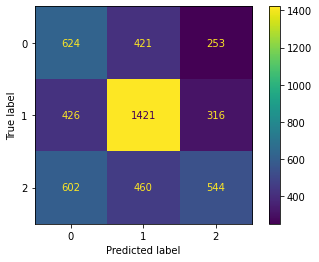

In [ ]:
eval_model(modalmodel, (data_test,labels_test))

#Section B:
**Now we are to use a transformer model as a backbone**

##essential imports

In [3]:
!pip install -q transformers

In [4]:
from transformers import AutoTokenizer, VisualBertForVisualReasoning
from transformers import BertConfig, BertTokenizer
from transformers import BertModel, AutoModel, BertForSequenceClassification
from transformers import AdamW
import torch
from torch.nn import BCEWithLogitsLoss as logit_bce

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


##Configurations

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [96]:
# general config
VIS_EMB_DIM=1408
TXT_EMB_DIM=768

TRAIN_DATA_SIZE=40
TEST_DATA_SIZE=10

TRAIN_BATCH_SIZE = 240
TEST_BATCH_SIZE = 240

In [104]:
model = VisualBertForVisualReasoning.from_pretrained("uclanlp/visualbert-nlvr2",
                                                    num_labels = 3,
                                                    output_attentions=False,
                                                    output_hidden_states=False,
                                                    visual_embedding_dim = VIS_EMB_DIM,
                                                    ignore_mismatched_sizes=True)

model = model.to(device)

Some weights of VisualBertForVisualReasoning were not initialized from the model checkpoint at uclanlp/visualbert-nlvr2 and are newly initialized because the shapes did not match:
- visual_bert.embeddings.visual_projection.weight: found shape torch.Size([768, 1024]) in the checkpoint and torch.Size([768, 1408]) in the model instantiated
- cls.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
- cls.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([3]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


##Preparing suitable datasets for the process
**Since we are dealing with a somewhat different data from the original data we used to work on; we now need a dataset compatible with the new data**

In [12]:
class Final_Emb_Dataset (Dataset):
  def __init__(self, dataset_dir, visual_embedded_dir, visual_file_len, transform=None):

    self.visual_embedded_path = dataset_dir +"/"+ visual_embedded_dir
    self.transform = transform

    self.sentiments = torch.load(self.visual_embedded_path+"/labels_0.pt")
    self.vectors = torch.load(self.visual_embedded_path+"/vectors_0.pt")
    for i in range(1,visual_file_len):
      self.sentiments = torch.cat((self.sentiments,torch.load(self.visual_embedded_path+f"/labels_{i}.pt")))
      self.vectors = torch.cat((self.vectors,torch.load(self.visual_embedded_path+f"/vectors_{i}.pt")))

    self.length= self.vectors.size()[0]

    
  def __len__(self):
        return self.length

  def __getitem__(self, idx):
        sentiment = self.sentiments[idx]
        image = self.vectors[idx,-VIS_EMB_DIM:]
        text = self.vectors[idx,:TXT_EMB_DIM]
        return text,image,sentiment

In [150]:
# def bert_preprocess(text):
#     return tokenizer.encode_plus(
#         text,
#         max_length=MAX_LEN,
#         truncation=True,
#         add_special_tokens=True,
#         return_token_type_ids=True,
#         return_attention_mask=True,
#         padding='max_length',
#         return_tensors='pt',
#     )

In [13]:
transform = T.Compose([T.ToTensor()])

trainset = Final_Emb_Dataset('dataset/train','cated_data', TRAIN_DATA_SIZE,transform=transform)
testset = Final_Emb_Dataset('dataset/test', 'cated_data', TEST_DATA_SIZE,transform=transform)

In [97]:
train_loader = DataLoader(trainset, batch_size=TRAIN_BATCH_SIZE, shuffle=True)
test_loader = DataLoader(testset, batch_size=TEST_BATCH_SIZE, shuffle=False)

##Training

In [15]:
average_policy = 'macro'
metrics = {'accuracy': accuracy_score, 'precision': lambda y1, y2: precision_score(y1, y2, average=average_policy),
           'recall': lambda y1, y2: recall_score(y1, y2, average=average_policy),
           'f1': lambda y1, y2: f1_score(y1, y2, average=average_policy),
           'confusion_matrix': confusion_matrix}


In [16]:
def onehot(y):
  out = torch.zeros((y.size()[0],3),device=device)
  for i,index in enumerate(y):
    out[i,index.item()] = 1
  return out

In [105]:
import tqdm

def one_epoch(model, loader, criterion, optimizer=None, epoch='', train=True, set_name='Train', metrics=None):
    total_loss = 0
    N = len(loader.dataset)
    Y = []
    Y_pred = []
    Accs = []
    if train:
        model.train()
    else:
        model.eval()

    with torch.set_grad_enabled(train), tqdm.tqdm(enumerate(loader), total=len(loader)) as pbar:
        for i, data_i in pbar:
            if train:
                optimizer.zero_grad()

            text, image, y = data_i[0], data_i[1], data_i[2]

            inputs_embeds = text.unsqueeze(1).to(torch.float)
            visual_embeds = image.unsqueeze(1)
            visual_token_type_ids = torch.ones(visual_embeds.shape[:-1], dtype=torch.long, device=device)
            visual_attention_mask = torch.ones(visual_embeds.shape[:-1], dtype=torch.float, device= device)
            labels = y.unsqueeze(0).to(torch.long)
            inputs=(
                {
                    "inputs_embeds" : inputs_embeds,
                    "visual_embeds": visual_embeds,
                    "visual_token_type_ids": visual_token_type_ids,
                    "visual_attention_mask": visual_attention_mask,
                }
            )

            outputs = model(**inputs, labels=labels)
            #loss = outputs.loss
            scores = outputs.logits
            loss = criterion(scores, onehot(y.long()))
            

            total_loss += loss.item() * len(y)

            if train:
                loss.backward()
                optimizer.step()
                

            y_pred = scores.argmax(dim=-1)
            Y.append(y.cpu().numpy())
            Y_pred.append(y_pred.cpu().numpy())

            Accs.append(np.count_nonzero(y_pred.cpu().numpy() == y.cpu().numpy())/len(y))
            pbar.set_description(f'{epoch}: {set_name} Loss: {total_loss / N:.3e}, acc : {sum(Accs)/len(Accs)*100:.4f}%')


    total_loss /= N

    Y = np.concatenate(Y)
    Y_pred = np.concatenate(Y_pred)
    acc = accuracy_score(Y_pred, Y)
    print(f'Accuracy of {set_name} set: {acc}')

    result = {'loss': total_loss, 'accuracy': acc}
    if metrics is not None:
        result.update({metric: metric_func(Y, Y_pred) for metric, metric_func in metrics.items()})

    return result

In [99]:
def train_model(model, dataloaders, num_epochs, criterion, optimizer, model_name='visualbert-model', scheduler=None):
    train_loader, val_loader = dataloaders
    min_val_loss = np.inf
    max_val_acc = 0

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        result = one_epoch(model, train_loader, criterion, optimizer, epoch, train=True, set_name='Train')
        train_loss = result['loss']
        train_acc = result['accuracy']
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_result = one_epoch(model, val_loader, criterion, epoch=epoch, train=False, set_name='Validation')
        val_loss = val_result['loss']
        val_acc = val_result['accuracy']
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        print('\n', '-' * 60)

        if val_loss < min_val_loss:
            min_val_loss = val_loss
            
        if val_acc > max_val_acc:
            max_val_acc = val_acc
            torch.save(model.state_dict(), f'models/{model_name}.pt')

        if scheduler:
            scheduler.step(val_loss)

    plt.plot(train_losses, label='train')
    plt.plot(val_losses, label='val')
    plt.title('loss history of training and val sets')
    plt.legend()
    plt.show()

    plt.plot(train_accuracies, label='train')
    plt.plot(val_accuracies, label='val')
    plt.title('Accuracy history of training and val sets')
    plt.legend()
    plt.show()

    model.load_state_dict(torch.load(f'models/{model_name}.pt'))
    return model, min_val_loss

In [106]:
LEARNING_RATE = 1e-4
EPSILON = 5e-8
EPOCHS = 5

In [107]:
optimizer = torch.optim.AdamW(model.parameters(),lr = LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, verbose=True, factor=0.5)
criterion = logit_bce()

0: Train Loss: 5.829e-01, acc : 51.4902%: 100%|██████████| 85/85 [00:11<00:00,  7.57it/s]


Accuracy of Train set: 0.5146245059288538


0: Validation Loss: 6.242e-01, acc : 44.8064%: 100%|██████████| 22/22 [00:00<00:00, 26.94it/s]


Accuracy of Validation set: 0.44977304124728634

 ------------------------------------------------------------


1: Train Loss: 5.656e-01, acc : 53.7059%: 100%|██████████| 85/85 [00:11<00:00,  7.50it/s]


...

Accuracy of Validation set: 0.5261495954213539

 ------------------------------------------------------------


4: Train Loss: 5.424e-01, acc : 57.8186%: 100%|██████████| 85/85 [00:11<00:00,  7.53it/s]


Accuracy of Train set: 0.5784090909090909


4: Validation Loss: 6.131e-01, acc : 51.0248%: 100%|██████████| 22/22 [00:00<00:00, 26.82it/s]


Accuracy of Validation set: 0.5052299190842707

 ------------------------------------------------------------


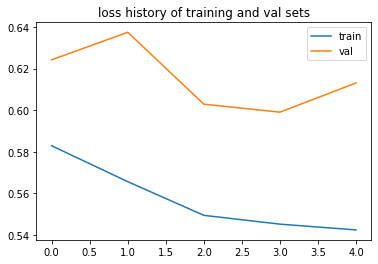

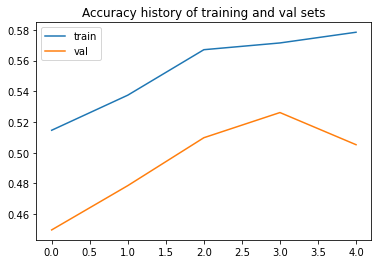

In [108]:
model, min_val_loss = train_model(model, 
                                  (train_loader, test_loader), 
                                  EPOCHS, 
                                  criterion, 
                                  optimizer, 
                                  model_name='visualbert_cnn_alt_second', 
                                  scheduler=None)

##Evaluation

In [69]:
def eval_model(model, loader, metrics=metrics, set_name='Test', plot_confusion_matrix=True):
    results = one_epoch(model, loader, criterion, train=False, set_name=set_name, metrics=metrics)
    disp = ConfusionMatrixDisplay(results.pop('confusion_matrix'))
    if plot_confusion_matrix:
        disp.plot()
    return results

: Test Loss: 5.847e-01, acc : 53.1460%: 100%|██████████| 22/22 [00:01<00:00, 11.31it/s]


Accuracy of Test set: 0.5273337280442076


{'loss': 0.5847306788285291,
 'accuracy': 0.5273337280442076,
 'precision': 0.4995780017875528,
 'recall': 0.4943013850730122,
 'f1': 0.4935012725034298}

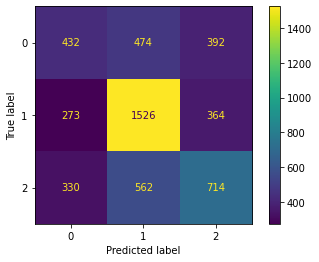

In [110]:
model.load_state_dict(torch.load('models/visualbert_cnn_alt.pt'))
eval_model(model, test_loader)

# Merged from Phase3_Part2.ipynb

In [ ]:
# https://drive.google.com/file/d/1blGgEOlrHrM0-NAQxYVRwMlfiHDvVHXb/view
!pip install --upgrade --no-cache-dir gdown
!gdown --id "1blGgEOlrHrM0-NAQxYVRwMlfiHDvVHXb"

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Attempting uninstall: gdown
    Found existing installation: gdown 4.4.0
    Uninstalling gdown-4.4.0:
      Successfully uninstalled gdown-4.4.0
/usr/local/lib/python3.8/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1blGgEOlrHrM0-NAQxYVRwMlfiHDvVHXb
To: /content/InstaNY100K.zip
100% 1.87G/1.87G [00:10<00:00, 175MB/s]


In [ ]:
!unzip InstaNY100K

In [ ]:
!pip install kaggle

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import json 

api = {"username":"a80abbasi","key":"c64917f1d1c750fbbeed83ac15b782e8"}
with open('kaggle.json', 'w') as f:
    json.dump(api, f)

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d hsankesara/flickr-image-dataset

User cancelled operation


In [ ]:
!unzip flickr-image-dataset.zip

unzip:  cannot find or open flickr-image-dataset.zip, flickr-image-dataset.zip.zip or flickr-image-dataset.zip.ZIP.


# Dataset

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms as T
from torch.utils.data import Dataset, DataLoader

In [ ]:
from PIL import Image
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [ ]:
# df = pd.read_csv('./flickr30k_images/results.csv', delimiter='|')

# df.head()

In [ ]:
class MultiModalDataset (Dataset):
  def __init__(self, dataset_dir, images_dir, texts, transform=None, preprocess_func=None, pad_idx=None, max_len=None):
    self.dataset_path = Path(dataset_dir)
    self.images_path = self.dataset_path / images_dir
    self.text_path = self.dataset_path / texts

    self.transform = transform

    self.preprocess_func = preprocess_func
    self.pad_idx = pad_idx
    self.max_len = max_len

    self.file_names = [(self.images_path/f).stem for f in os.listdir(self.images_path)]
    # shuffle
    self.file_names = np.random.permutation(self.file_names)
    
  def __len__(self):
        return len(self.file_names)

  def __getitem__(self, idx):
        img_path = self.images_path / f'{self.file_names[idx]}.jpg'
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
       
        text_path = self.text_path / f'{self.file_names[idx]}.txt'
        with open(text_path.absolute(), 'r') as f:
            text = f.read()

        if self.preprocess_func is not None:
            text = self.preprocess_func(text)
            if self.max_len is not None:
                text = text[:self.max_len]
            if self.pad_idx is not None:
                text = F.pad(torch.tensor(text), (0, self.max_len - len(text)), 'constant', self.pad_idx)
        
        return image, text

In [ ]:
# class MultiModalDataset (Dataset):
#   def __init__(self, dataset_dir, images_dir, texts, transform=None, preprocess_func=None, pad_idx=None, max_len=None):
#     self.dataset_path = Path(dataset_dir)
#     self.images_path = self.dataset_path / images_dir
#     self.text_path = self.dataset_path / texts

#     self.transform = transform

#     self.preprocess_func = preprocess_func
#     self.pad_idx = pad_idx
#     self.max_len = max_len

#     self.df = pd.read_csv(self.text_path, delimiter='|')
#     self.df.columns = [col.strip() for col in self.df.columns]
#     # shuffle
#     self.df = self.df.sample(frac=1).reset_index()
    
#   def __len__(self):
#         return len(self.df)

#   def __getitem__(self, idx):
#         img_path = self.images_path / self.df.loc[idx, 'image_name']
#         image = Image.open(img_path)

#         if self.transform:
#             image = self.transform(image)
       
#         text = self.df.loc[idx, 'comment']

#         if self.preprocess_func is not None:
#             text = self.preprocess_func(text)
#             if self.max_len is not None:
#                 text = text[:self.max_len]
#             if self.pad_idx is not None:
#                 text = F.pad(torch.tensor(text), (0, self.max_len - len(text)), 'constant', self.pad_idx)
        
#         return image, text

In [ ]:
# dataset = MultiModalDataset('./flickr30k_images', 'flickr30k_images', 'results.csv')

In [ ]:
dataset = MultiModalDataset('./InstaNY100K', 'img_resized/newyork', 'captions/newyork')

In [ ]:
len(dataset)

100000

In [ ]:
img, text = dataset[43]
text

"There's nothing you can't do. Now you're in New York. These streets will make you feel brand new. Big lights will inspire you. • • • #taglialatellagalleries #newyorkcity #chelsea #nyc #newyork #eastcoast #springtime #exploring #galleries  #art"

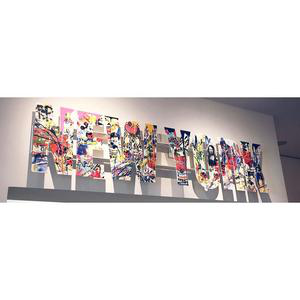

In [ ]:
img

## Processing Text

In [ ]:
!pip install pyenchant

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.7/55.7 KB 5.8 MB/s eta 0:00:00


In [ ]:
import nltk
import string
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

import enchant
english_dict = enchant.Dict("en_US")

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [ ]:
!pip install emoji

import emoji

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.9/240.9 KB 20.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-2.2.0-py3-none-any.whl size=234926 sha256=1c1802ee84dd0fa32ac56fd08993a7d51b4843ff991cb871517675dd14dc0708
  Stored in directory: /root/.cache/pip/wheels/86/62/9e/a6b27a681abcde69970dbc0326ff51955f3beac72f15696984
Successfully built emoji


In [ ]:
NUM = '<NUM>'
UNK = '<UNK>'

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


def sent_preprocess(sent, lower=True, remove_punct=True, remove_stopwords=False,
                    lemmatize=False, handle_nums=False, handle_unknowns=False, remove_emojies=True, join=True):
    if lower:
        sent = sent.lower()
    
    if remove_punct:
        sent = sent.translate(str.maketrans('', '', string.punctuation))

    if remove_emojies:
        sent = emoji.replace_emoji(sent)
    
    word_tokens = word_tokenize(sent)

    if remove_stopwords:
        word_tokens = [w for w in word_tokens if not w in stop_words]

    if lemmatize:
        word_tokens = [lemmatizer.lemmatize(w) for w in word_tokens]

    if handle_nums:
        
        def is_number(s):
            if s.isdigit():
                return True
            if s[:-2].isdigit():
                if s[-2:] == 'th' or s[-2:] == 'st' or s[-2:] == 'nd' or s[-2:] == 'rd':
                    return True
            return False

        word_tokens = [NUM if is_number(w) else w for w in word_tokens]

    if handle_unknowns:
        word_tokens = [w if english_dict.check(w) else UNK for w in word_tokens]

    if join:
        return ' '.join(word_tokens)

    return word_tokens

In [ ]:
sent_preprocess(text)

'theres nothing you cant do now youre in new york these streets will make you feel brand new big lights will inspire you • • • taglialatellagalleries newyorkcity chelsea nyc newyork eastcoast springtime exploring galleries art'

## Bert Config

In [ ]:
!pip install transformers

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 75.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.3/190.3 KB 22.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 104.4 MB/s eta 0:00:00


In [ ]:
from transformers import BertConfig, BertTokenizer, BertForSequenceClassification
from torchvision import transforms

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# general config
MAX_LEN = 30

TRAIN_BATCH_SIZE = 64
VALID_BATCH_SIZE = 64
TEST_BATCH_SIZE = 64

EPOCHS = 4
LEARNING_RATE = 5e-5

MODEL_NAME = 'bert-base-uncased'

In [ ]:
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
config = BertConfig.from_pretrained(MODEL_NAME)

In [ ]:
def bert_preprocess(text):
    # text = sent_preprocess(text)
    return tokenizer.encode_plus(
        text,
        max_length=MAX_LEN,
        truncation=True,
        add_special_tokens=True,
        return_token_type_ids=True,
        return_attention_mask=True,
        padding='max_length',
        return_tensors='pt',
    )

transform = transforms.Compose([transforms.ToTensor()
                                ,transforms.Resize((288,288),transforms.InterpolationMode("bicubic"))
                                ,transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])])   

In [ ]:
dataset = MultiModalDataset('./InstaNY100K', 'img_resized/newyork', 'captions/newyork', transform=transform, preprocess_func=bert_preprocess)

In [ ]:
train_size = int(0.1 * len(dataset))
val_size = int(0.02 * len(dataset))
test_size = int(0.02 * len(dataset))
train_size, val_size, test_size

(10000, 2000, 2000)

In [ ]:
train_set, val_set, test_set, _ = torch.utils.data.random_split(dataset, [train_size, val_size, test_size, len(dataset) - train_size - val_size - test_size])

In [ ]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

# Model

In [ ]:
!pip install --upgrade --no-cache-dir gdown

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# !gdown 11caq-CNLP6_V3106zj0zAkFyYPAjyjyw
!gdown 14Nh5c1pfzAuLF2nC3-IpugRi7eAMZvhW


from transformers import BertForSequenceClassification

def load_pretrained_bert(name='bert_model.pt'):
    model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
        num_labels = 3,
        output_attentions = False,
        output_hidden_states = False,
    )
    model.load_state_dict(torch.load(name, map_location=torch.device('cpu')))
    return model

Downloading...
From: https://drive.google.com/uc?id=14Nh5c1pfzAuLF2nC3-IpugRi7eAMZvhW
To: /content/bert_model.pt
100% 438M/438M [00:03<00:00, 111MB/s] 


In [ ]:
class lastLayer(nn.Module):
    def __init__(self, pretrained):
        super(lastLayer, self).__init__()
        self.pretrained = pretrained
        self.last = nn.Sequential(
            nn.Dropout(p = 0.2,inplace=True),
            nn.Linear(1408, 90),
            nn.Dropout(p = 0.3,inplace=True),
            nn.Linear(90, 30),
            nn.Dropout(p = 0.1,inplace=True),
            nn.Linear(30, 3),
            )
    
    def forward(self, x):
        x = self.pretrained(x)
        x = self.last(x)
        return x

In [ ]:
!gdown 1EfyDFNxAHGjvnLPRbP0SfnkV9g33-CFJ

from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights

def load_pretrained_image(name ='scene_modal_en.pth',device='cpu'):
    image_model = efficientnet_b2(weights=EfficientNet_B2_Weights.IMAGENET1K_V1)
    image_model.classifier = nn.Sequential()
    image_model = lastLayer(image_model)
    image_model.load_state_dict(torch.load(name,map_location=torch.device(device)))
    return image_model

Downloading...
From: https://drive.google.com/uc?id=1EfyDFNxAHGjvnLPRbP0SfnkV9g33-CFJ
To: /content/scene_modal_en.pth
100% 31.8M/31.8M [00:00<00:00, 163MB/s] 


# Training

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
import tqdm

def one_epoch(models, loader, criterion, optimizer=None, epoch='', train=True, set_name='Train', metrics=None):
    total_loss = 0
    N = len(loader.dataset)
    Y = []
    Y_pred = []
    text_model, image_model = models
    text_model.eval()
    if train:
        image_model.train()
    else:
        image_model.eval()

    with torch.set_grad_enabled(train), tqdm.tqdm(enumerate(loader), total=len(loader)) as pbar:
        for i, data_i in pbar:
            if train:
                optimizer.zero_grad()

            image, text = data_i
            image = image.to(device)
            input_ids = text['input_ids'].to(device)
            attention_mask = text['attention_mask'].to(device)
            token_type_ids = text['token_type_ids'].to(device)
            input_ids = input_ids.squeeze(1)
            attention_mask = attention_mask.squeeze(1)
            token_type_ids = token_type_ids.squeeze(1)

            output = text_model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
            p_text = output.logits
            p_image = image_model(image)

            y_pred = p_image.argmax(dim=-1)
            y_true = p_text.argmax(dim=-1)

            loss = criterion(p_text, p_image, y_true)

            total_loss += loss.item() * len(image)
            pbar.set_description(f'{epoch}: {set_name} Loss: {total_loss / N:.3e}')
            if train:
                loss.backward()
                optimizer.step()

            Y.append(y_true.cpu().numpy())
            Y_pred.append(y_pred.cpu().numpy())

    total_loss /= N

    Y = np.concatenate(Y)
    Y_pred = np.concatenate(Y_pred)
    acc = accuracy_score(Y_pred, Y)
    print(f'Accuracy of {set_name} set: {acc}')

    result = {'loss': total_loss, 'accuracy': acc}
    if metrics is not None:
        result.update({metric: metric_func(Y, Y_pred) for metric, metric_func in metrics.items()})

    return result

In [ ]:
def train_model(models, dataloaders, num_epochs, criterion, optimizer, model_name='pytroch-model', scheduler=None):
    train_loader, val_loader = dataloaders
    min_val_loss = np.inf

    text_model, image_model = models

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        result = one_epoch(models, train_loader, criterion, optimizer, epoch, train=True, set_name='Train')
        train_loss = result['loss']
        train_acc = result['accuracy']
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_result = one_epoch(models, val_loader, criterion, epoch=epoch, train=False, set_name='Validation')
        val_loss = val_result['loss']
        val_acc = val_result['accuracy']
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        print('\n', '-' * 60)

        if val_loss < min_val_loss:
            min_val_loss = val_loss
            torch.save(image_model.state_dict(), f'{model_name}.pt')

        if scheduler:
            scheduler.step(val_loss)

    plt.plot(train_losses, label='train')
    plt.plot(val_losses, label='val')
    plt.title('loss history of training and val sets')
    plt.legend()
    plt.show()

    plt.plot(train_accuracies, label='train')
    plt.plot(val_accuracies, label='val')
    plt.title('Accuracy history of training and val sets')
    plt.legend()
    plt.show()

    image_model.load_state_dict(torch.load(f'{model_name}.pt'))
    return image_model, min_val_loss

In [ ]:
text_model = load_pretrained_bert()
text_model.requires_grad_(False)
text_model.eval()
text_model.to(device)

image_model = load_pretrained_image()
image_model.to(device);

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.decoder.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at

In [ ]:
class DistillationLoss(nn.Module):
    def __init__(self, alpha=0.9, T=2):
        super().__init__()
        self.alpha = alpha
        self.T = T
        self.kl_div = nn.KLDivLoss(log_target=True, reduction="batchmean")
        self.cross_entropy = nn.CrossEntropyLoss()

    def forward(self, p_true, p_pred, y_true):
        logit_loss = self.kl_div(F.log_softmax(p_pred / self.T, dim=-1), F.log_softmax(p_true / self.T, dim=-1)) 
        label_loss = self.cross_entropy(p_pred, y_true)
        return (1-self.alpha) * label_loss + self.alpha * self.T * self.T * logit_loss

In [ ]:
# Training Configuration
LEARNING_RATE = 5e-4
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, image_model.parameters()), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, verbose=True, factor=0.5)
criterion = DistillationLoss(alpha=0.5)

In [ ]:
import torch, gc

gc.collect()
torch.cuda.empty_cache()
pt_model = None

!nvidia-smi

Fri Feb 10 22:14:24 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 510.47.03    Driver Version: 510.47.03    CUDA Version: 11.6     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   74C    P0    38W /  70W |   2530MiB / 15360MiB |     88%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

average_policy = 'macro'
metrics = {'accuracy': accuracy_score, 'precision': lambda y1, y2: precision_score(y1, y2, average=average_policy),
           'recall': lambda y1, y2: recall_score(y1, y2, average=average_policy),
           'f1': lambda y1, y2: f1_score(y1, y2, average=average_policy),
           'confusion_matrix': confusion_matrix}

In [ ]:
def eval_model(models, loader, metrics=metrics, set_name='Test', plot_confusion_matrix=True):
    results = one_epoch(models, loader, criterion, train=False, set_name=set_name, metrics=metrics)
    disp = ConfusionMatrixDisplay(results.pop('confusion_matrix'))
    if plot_confusion_matrix:
        disp.plot()
    return results

### Before training:

: Test Loss: 5.393e-01: 100%|██████████| 63/63 [00:26<00:00,  2.39it/s]

Accuracy of Test set: 0.4135


{'loss': 0.539263695716858,
 'accuracy': 0.4135,
 'precision': 0.3334334159610475,
 'recall': 0.33438849213615734,
 'f1': 0.30243937000968746}

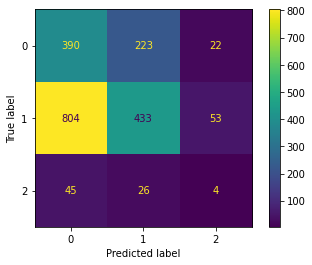

In [ ]:
eval_model((text_model, image_model), test_loader)

0: Train Loss: 4.780e-01: 100%|██████████| 313/313 [03:44<00:00,  1.40it/s]


Accuracy of Train set: 0.638


0: Validation Loss: 4.769e-01: 100%|██████████| 63/63 [00:26<00:00,  2.40it/s]


Accuracy of Validation set: 0.6285

 ------------------------------------------------------------


1: Train Loss: 4.690e-01: 100%|██████████| 313/313 [03:43<00:00,  1.40it/s]


Accuracy of Train set: 0.6432


1: Validation Loss: 4.806e-01: 100%|██████████| 63/63 [00:26<00:00,  2.41it/s]


Accuracy of Validation set: 0.6285

 ------------------------------------------------------------


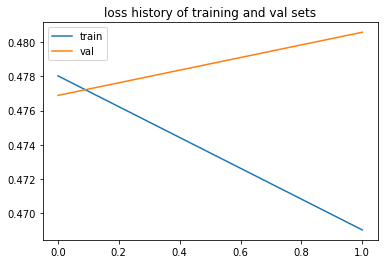

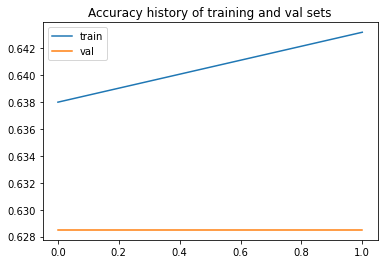

In [ ]:
# image_model = load_pretrained_image()
# image_model.to(device);

EPOCH = 2
image_model, min_val_loss = train_model((text_model, image_model), (train_loader, val_loader), EPOCH, criterion, optimizer, model_name='weakly_sup', scheduler=scheduler)

: Test Loss: 4.745e-01: 100%|██████████| 63/63 [00:27<00:00,  2.32it/s]

Accuracy of Test set: 0.645



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'loss': 0.4745474536418915,
 'accuracy': 0.645,
 'precision': 0.215,
 'recall': 0.3333333333333333,
 'f1': 0.26139817629179335}

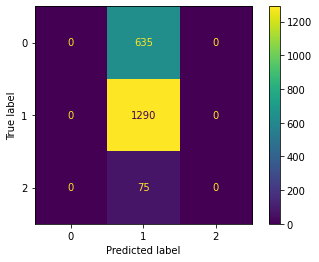

In [ ]:
eval_model((text_model, image_model), test_loader)

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# %/content/drive
# torch.save(text_model.state_dict(), f'bert_model.pt')

# Merged from Phase3_Part2_2nd_dataset.ipynb

<a href="https://colab.research.google.com/github/Nikelroid/DeepLearning_Project/blob/main/Phase-3/phase3_part2_2nd_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# https://drive.google.com/file/d/1blGgEOlrHrM0-NAQxYVRwMlfiHDvVHXb/view
#!pip install --upgrade --no-cache-dir gdown
#!gdown --id "1blGgEOlrHrM0-NAQxYVRwMlfiHDvVHXb"

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Attempting uninstall: gdown
    Found existing installation: gdown 4.4.0
    Uninstalling gdown-4.4.0:
      Successfully uninstalled gdown-4.4.0
/usr/local/lib/python3.8/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1blGgEOlrHrM0-NAQxYVRwMlfiHDvVHXb
To: /content/InstaNY100K.zip
100% 1.87G/1.87G [00:10<00:00, 175MB/s]


In [ ]:
#!unzip InstaNY100K

In [4]:
!pip install kaggle

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [5]:
import json 

api = {"username":"a80abbasi","key":"c64917f1d1c750fbbeed83ac15b782e8"}
with open('kaggle.json', 'w') as f:
    json.dump(api, f)

In [6]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d hsankesara/flickr-image-dataset

100% 8.16G/8.16G [05:59<00:00, 24.3MB/s]
100% 8.16G/8.16G [05:59<00:00, 24.4MB/s]


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
!cp flickr-image-dataset.zip drive/MyDrive

In [ ]:
!unzip flickr-image-dataset.zip

# Dataset

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms as T
from torch.utils.data import Dataset, DataLoader

In [18]:
from PIL import Image
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from torchvision import transforms

In [14]:
df = pd.read_csv('./flickr30k_images/results.csv', delimiter='|')
df.head()

,image_name,comment_number,comment
0,1000092795.jpg,0,Two young guys with shaggy hair look at their...
1,1000092795.jpg,1,"Two young , White males are outside near many..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .


In [15]:
class MultiModalDataset (Dataset):
  def __init__(self, dataset_dir, images_dir, texts, transform=None, preprocess_func=None, pad_idx=None, max_len=None):
    self.dataset_path = Path(dataset_dir)
    self.images_path = self.dataset_path / images_dir
    self.text_path = self.dataset_path / texts

    self.transform = transform

    self.preprocess_func = preprocess_func
    self.pad_idx = pad_idx
    self.max_len = max_len

    self.file_names = [(self.images_path/f).stem for f in os.listdir(self.images_path)]
    # shuffle
    self.file_names = np.random.permutation(self.file_names)
    
  def __len__(self):
        return len(self.file_names)

  def __getitem__(self, idx):
        img_path = self.images_path / f'{self.file_names[idx]}.jpg'
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
       
        text_path = self.text_path / f'{self.file_names[idx]}.txt'
        with open(text_path.absolute(), 'r') as f:
            text = f.read()

        if self.preprocess_func is not None:
            text = self.preprocess_func(text)
            if self.max_len is not None:
                text = text[:self.max_len]
            if self.pad_idx is not None:
                text = F.pad(torch.tensor(text), (0, self.max_len - len(text)), 'constant', self.pad_idx)
        
        return image, text

In [16]:
class MultiModalDataset (Dataset):
  def __init__(self, dataset_dir, images_dir, texts, transform, preprocess_func=None, pad_idx=None, max_len=None):
    self.dataset_path = Path(dataset_dir)
    self.images_path = self.dataset_path / images_dir
    self.text_path = self.dataset_path / texts
    self.transform = transform

    self.preprocess_func = preprocess_func
    self.pad_idx = pad_idx
    self.max_len = max_len

    self.df = pd.read_csv(self.text_path, delimiter='|')
    self.df.columns = [col.strip() for col in self.df.columns]
    # shuffle
    self.df = self.df.sample(frac=1).reset_index()
    
  def __len__(self):
        return len(self.df)

  def __getitem__(self, idx):
        img_path = self.images_path / self.df.loc[idx, 'image_name']
        image = Image.open(img_path)

        if self.transform:
            image = self.transform(image)
       
        text = self.df.loc[idx, 'comment']

        if self.preprocess_func is not None:
            text = self.preprocess_func(text)
            if self.max_len is not None:
                text = text[:self.max_len]
            if self.pad_idx is not None:
                text = F.pad(torch.tensor(text), (0, self.max_len - len(text)), 'constant', self.pad_idx)
        
        return image, text

In [26]:
!pip install transformers

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 53.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 61.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.3/190.3 KB 22.2 MB/s eta 0:00:00


In [27]:
from transformers import BertConfig, BertTokenizer, BertForSequenceClassification
from torchvision import transforms

In [28]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# general config
MAX_LEN = 30

TRAIN_BATCH_SIZE = 64
VALID_BATCH_SIZE = 64
TEST_BATCH_SIZE = 64

EPOCHS = 4
LEARNING_RATE = 5e-5

MODEL_NAME = 'bert-base-uncased'

In [29]:
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
config = BertConfig.from_pretrained(MODEL_NAME)

In [30]:
def bert_preprocess(text):
    # text = sent_preprocess(text)
    return tokenizer.encode_plus(
        text,
        max_length=MAX_LEN,
        truncation=True,
        add_special_tokens=True,
        return_token_type_ids=True,
        return_attention_mask=True,
        padding='max_length',
        return_tensors='pt',
    )
transform = transforms.Compose([transforms.ToTensor()
                                ,transforms.Resize((288,288),transforms.InterpolationMode("bicubic"))
                                ,transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])])    

In [31]:

dataset = MultiModalDataset('./flickr30k_images', 'flickr30k_images', 'results.csv',transform, preprocess_func=bert_preprocess)

In [ ]:
#dataset = MultiModalDataset('./InstaNY100K', 'img_resized/newyork', 'captions/newyork')

In [32]:
len(dataset)

158915

In [ ]:
img, text = dataset[43]
text

In [34]:
img

tensor([[[-1.3818, -1.9197, -1.9686,  ...,  0.5188, -0.6799, -0.6316],
         [-1.9895, -1.8757, -1.8665,  ..., -1.1366, -2.0356, -1.4746],
         [-1.7962, -2.0888, -1.3564,  ..., -1.6798, -2.0171, -1.7802],
         ...,
         [ 0.2269,  0.3553,  0.4122,  ...,  0.3937,  0.3174,  0.3952],
         [ 0.1254, -0.0502,  0.1406,  ...,  0.5410,  0.4618,  0.4655],
         [ 0.0707,  0.3586, -0.1358,  ...,  0.4350,  0.3138,  0.1520]],

        [[-1.0963, -1.7122, -1.5233,  ..., -0.0772, -0.3560,  0.0655],
         [-1.5795, -1.7441, -1.6194,  ..., -1.1331, -1.6792, -1.3218],
         [-1.5405, -1.2322, -1.4460,  ..., -1.5483, -1.6548, -1.6470],
         ...,
         [-0.1801, -0.2133, -0.1930,  ..., -0.0290,  0.0090, -0.2076],
         [-0.3749, -0.3939, -0.2801,  ..., -0.2162, -0.1988, -0.2779],
         [-0.2827, -0.4019, -0.2831,  ..., -0.1332, -0.3245, -0.4826]],

        [[-0.5485, -1.6273, -1.5566,  ...,  0.4323,  0.5779,  0.9507],
         [-1.3320, -1.5721, -1.3405,  ..., -0

## Processing Text

In [35]:
!pip install pyenchant

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.7/55.7 KB 6.3 MB/s eta 0:00:00


In [36]:
import nltk
import string
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

import enchant
english_dict = enchant.Dict("en_US")

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [37]:
!pip install emoji

import emoji

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.9/240.9 KB 10.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-2.2.0-py3-none-any.whl size=234926 sha256=cbfa5be6c0e2c7f3f0cbf0e9f537676c66c8e9a1a989cda28a5ada9475c7f2a8
  Stored in directory: /root/.cache/pip/wheels/86/62/9e/a6b27a681abcde69970dbc0326ff51955f3beac72f15696984
Successfully built emoji


In [38]:
NUM = '<NUM>'
UNK = '<UNK>'

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


def sent_preprocess(sent, lower=True, remove_punct=True, remove_stopwords=False,
                    lemmatize=False, handle_nums=False, handle_unknowns=False, remove_emojies=True, join=True):
    if lower:
        sent = sent.lower()
    
    if remove_punct:
        sent = sent.translate(str.maketrans('', '', string.punctuation))

    if remove_emojies:
        sent = emoji.replace_emoji(sent)
    
    word_tokens = word_tokenize(sent)

    if remove_stopwords:
        word_tokens = [w for w in word_tokens if not w in stop_words]

    if lemmatize:
        word_tokens = [lemmatizer.lemmatize(w) for w in word_tokens]

    if handle_nums:
        
        def is_number(s):
            if s.isdigit():
                return True
            if s[:-2].isdigit():
                if s[-2:] == 'th' or s[-2:] == 'st' or s[-2:] == 'nd' or s[-2:] == 'rd':
                    return True
            return False

        word_tokens = [NUM if is_number(w) else w for w in word_tokens]

    if handle_unknowns:
        word_tokens = [w if english_dict.check(w) else UNK for w in word_tokens]

    if join:
        return ' '.join(word_tokens)

    return word_tokens

## Bert Config

In [ ]:
#dataset = MultiModalDataset('./InstaNY100K', 'img_resized/newyork', 'captions/newyork', transform=transform, preprocess_func=bert_preprocess)

In [79]:
train_size = int(0.3 * len(dataset))
val_size = int(0.06 * len(dataset))
test_size = int(0.06 * len(dataset))
train_size, val_size, test_size

(47674, 9534, 9534)

In [41]:
train_set, val_set, test_set, _ = torch.utils.data.random_split(dataset, [train_size, val_size, test_size, len(dataset) - train_size - val_size - test_size])

In [80]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

# Model

In [43]:
!pip install --upgrade --no-cache-dir gdown

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Attempting uninstall: gdown
    Found existing installation: gdown 4.4.0
    Uninstalling gdown-4.4.0:
      Successfully uninstalled gdown-4.4.0


In [46]:
%cd drive/MyDrive

/content/drive/MyDrive


In [72]:
# !gdown 11caq-CNLP6_V3106zj0zAkFyYPAjyjyw
#!gdown 14Nh5c1pfzAuLF2nC3-IpugRi7eAMZvhW


from transformers import BertForSequenceClassification

def load_pretrained_bert(name='drive/MyDrive/models/bert_model.pt'):
    model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
        num_labels = 3,
        output_attentions = False,
        output_hidden_states = False,
    )
    model.load_state_dict(torch.load(name))
    return model

In [48]:
class lastLayer(nn.Module):
    def __init__(self, pretrained):
        super(lastLayer, self).__init__()
        self.pretrained = pretrained
        self.last = nn.Sequential(
            nn.Dropout(p = 0.2,inplace=True),
            nn.Linear(1408, 90),
            nn.Dropout(p = 0.3,inplace=True),
            nn.Linear(90, 30),
            nn.Dropout(p = 0.1,inplace=True),
            nn.Linear(30, 3),
            )
    
    def forward(self, x):
        x = self.pretrained(x)
        x = self.last(x)
        return x

In [73]:
#!gdown 1EfyDFNxAHGjvnLPRbP0SfnkV9g33-CFJ

from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights

def load_pretrained_image(name ='drive/MyDrive/models/scene_modal_en.pth'):
    image_model = efficientnet_b2(weights=EfficientNet_B2_Weights.IMAGENET1K_V1)
    image_model.classifier = nn.Sequential()
    image_model = lastLayer(image_model)
    image_model.load_state_dict(torch.load(name))
    return image_model

# Training

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [51]:
import tqdm

def one_epoch(models, loader, criterion, optimizer=None, epoch='', train=True, set_name='Train', metrics=None):
    tmp_accs = []
    total_loss = 0
    N = len(loader.dataset)
    Y = []
    Y_pred = []
    text_model, image_model = models
    text_model.eval()
    if train:
        image_model.train()
    else:
        image_model.eval()

    with torch.set_grad_enabled(train), tqdm.tqdm(enumerate(loader), total=len(loader)) as pbar:
        for i, data_i in pbar:
            if train:
                optimizer.zero_grad()
            image, text = data_i
            image = image.to(device)
            input_ids = text['input_ids'].to(device)
            attention_mask = text['attention_mask'].to(device)
            token_type_ids = text['token_type_ids'].to(device)
            input_ids = input_ids.squeeze(1)
            attention_mask = attention_mask.squeeze(1)
            token_type_ids = token_type_ids.squeeze(1)

            output = text_model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
            p_text = output.logits
            p_image = image_model(image)

            y_pred = p_image.argmax(dim=-1)
            y_true = p_text.argmax(dim=-1)

            loss = criterion(p_text, p_image, y_true)
            tmp_accs.append(np.count_nonzero(y_pred.cpu()==y_true.cpu()) / len(y_true.cpu()))
            total_loss += loss.item() * len(image)
            pbar.set_description(f'{epoch}: {set_name} Loss: {total_loss / (i+1):.3e} - Accuracy: {sum(tmp_accs)*100/len(tmp_accs):.2f}%')
            if train:
                loss.backward()
                optimizer.step()

            Y.append(y_true.cpu().numpy())
            Y_pred.append(y_pred.cpu().numpy())

    total_loss /= N

    Y = np.concatenate(Y)
    Y_pred = np.concatenate(Y_pred)
    acc = accuracy_score(Y_pred, Y)
    print(f'Accuracy of {set_name} set: {acc}')

    result = {'loss': total_loss, 'accuracy': acc}
    if metrics is not None:
        result.update({metric: metric_func(Y, Y_pred) for metric, metric_func in metrics.items()})

    return result

In [52]:
def train_model(models, dataloaders, num_epochs, criterion, optimizer, model_name='pytroch-model', scheduler=None):
    train_loader, val_loader = dataloaders
    min_val_loss = np.inf

    text_model, image_model = models

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        result = one_epoch(models, train_loader, criterion, optimizer, epoch, train=True, set_name='Train')
        train_loss = result['loss']
        train_acc = result['accuracy']
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_result = one_epoch(models, val_loader, criterion, epoch=epoch, train=False, set_name='Validation')
        val_loss = val_result['loss']
        val_acc = val_result['accuracy']
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        print('\n', '-' * 60)

        if val_loss < min_val_loss:
            min_val_loss = val_loss
            torch.save(image_model.state_dict(), f'{model_name}.pt')

        if scheduler:
            scheduler.step(val_loss)

    plt.plot(train_losses, label='train')
    plt.plot(val_losses, label='val')
    plt.title('loss history of training and val sets')
    plt.legend()
    plt.show()

    plt.plot(train_accuracies, label='train')
    plt.plot(val_accuracies, label='val')
    plt.title('Accuracy history of training and val sets')
    plt.legend()
    plt.show()

    image_model.load_state_dict(torch.load(f'{model_name}.pt'))
    return image_model, min_val_loss

In [76]:
text_model = load_pretrained_bert()
text_model.requires_grad_(False)
text_model.eval()
text_model = text_model.to(device)

image_model = load_pretrained_image()
image_model = image_model.to(device)

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.decoder.weight', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at

In [54]:
class DistillationLoss(nn.Module):
    def __init__(self, alpha=0.9, T=2):
        super().__init__()
        self.alpha = alpha
        self.T = T
        self.kl_div = nn.KLDivLoss(log_target=True, reduction="batchmean")
        self.cross_entropy = nn.CrossEntropyLoss()

    def forward(self, p_true, p_pred, y_true):
        logit_loss = self.kl_div(F.log_softmax(p_pred / self.T, dim=-1), F.log_softmax(p_true / self.T, dim=-1)) 
        label_loss = self.cross_entropy(p_pred, y_true)
        return (1-self.alpha) * label_loss + self.alpha * self.T * self.T * logit_loss

In [77]:
# Training Configuration
LEARNING_RATE = 1e-5
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, image_model.parameters()), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, verbose=True, factor=0.5)
criterion = DistillationLoss(alpha=0.9)

In [ ]:
import torch, gc

gc.collect()
torch.cuda.empty_cache()
pt_model = None

!nvidia-smi

In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

average_policy = 'macro'
metrics = {'accuracy': accuracy_score, 'precision': lambda y1, y2: precision_score(y1, y2, average=average_policy),
           'recall': lambda y1, y2: recall_score(y1, y2, average=average_policy),
           'f1': lambda y1, y2: f1_score(y1, y2, average=average_policy),
           'confusion_matrix': confusion_matrix}

In [82]:
def eval_model(models, loader, metrics=metrics, set_name='Test', plot_confusion_matrix=True):
    results = one_epoch(models, loader, criterion, train=False, set_name=set_name, metrics=metrics)
    disp = ConfusionMatrixDisplay(results.pop('confusion_matrix'))
    if plot_confusion_matrix:
        disp.plot()
    return results

### Before training:

In [60]:
#%cd ../..

/content


: Test Loss: 2.472e+01 - Accuracy: 44.73%: 100%|██████████| 50/50 [00:48<00:00,  1.02it/s]

Accuracy of Test set: 0.44808055380742606



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'loss': 0.3888651454988855,
 'accuracy': 0.44808055380742606,
 'precision': 0.3333333333333333,
 'recall': 0.14936018460247535,
 'f1': 0.20628712154135884}

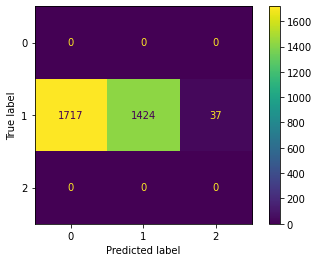

In [83]:
eval_model((text_model, image_model), test_loader)

In [62]:
# image_model = load_pretrained_image()
# image_model.to(device);

EPOCH = 2
image_model, min_val_loss = train_model((text_model, image_model), (train_loader, val_loader), EPOCH, criterion, optimizer, model_name='weakly_sup', scheduler=scheduler)

0: Train Loss: 2.472e+01 - Accuracy: 83.52%:   2%|▏         | 11/497 [00:12<08:50,  1.09s/it]


TypeError: ignored

: Test Loss: 2.542e+01 - Accuracy: 79.95%: 100%|██████████| 100/100 [00:56<00:00,  1.76it/s]

Accuracy of Test set: 0.8001887979861548



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'loss': 0.7998910656959625,
 'accuracy': 0.8001887979861548,
 'precision': 0.3333333333333333,
 'recall': 0.26672959932871826,
 'f1': 0.2963351395443687}

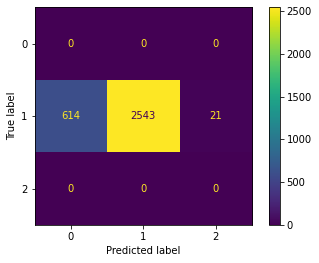

In [63]:
eval_model((text_model, image_model), test_loader)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd content/drive/MyDrive
torch.save(text_model.state_dict(), 'models/bert_model_weak_sup.pt')
torch.save(image_model.state_dict(), 'models/scene_model_weak_sup.pt')

# Merged from Phase3_Part2_debugged.ipynb

<a href="https://colab.research.google.com/github/Nikelroid/DeepLearning_Project/blob/main/Phase-3/Phase3_Part2_debugged.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# https://drive.google.com/file/d/1blGgEOlrHrM0-NAQxYVRwMlfiHDvVHXb/view
#!pip install --upgrade --no-cache-dir gdown
#!gdown --id "1blGgEOlrHrM0-NAQxYVRwMlfiHDvVHXb"

In [ ]:
#!unzip InstaNY100K

In [7]:
!pip install kaggle

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [8]:
import json 

api = {"username":"a80abbasi","key":"c64917f1d1c750fbbeed83ac15b782e8"}
with open('kaggle.json', 'w') as f:
   json.dump(api, f)

In [9]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [10]:
!kaggle datasets download -d hsankesara/flickr-image-dataset

100% 8.15G/8.16G [00:56<00:00, 173MB/s]
100% 8.16G/8.16G [00:56<00:00, 155MB/s]


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#!cp drive/MyDrive/flickr-image-dataset.zip /

In [ ]:
!unzip flickr-image-dataset.zip

# Dataset

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms as T
from torch.utils.data import Dataset, DataLoader

In [5]:
from PIL import Image
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from torchvision import transforms

In [12]:
df = pd.read_csv('./flickr30k_images/results.csv', delimiter='|')
df = df.dropna()
df.head()

,image_name,comment_number,comment
0,1000092795.jpg,0,Two young guys with shaggy hair look at their...
1,1000092795.jpg,1,"Two young , White males are outside near many..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .


In [119]:
df[' comment'].eq('').sum()

0

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# general config
MAX_LEN = 30

TRAIN_BATCH_SIZE = 64
VALID_BATCH_SIZE = 64
TEST_BATCH_SIZE = 64

EPOCHS = 4
LEARNING_RATE = 5e-5

MODEL_NAME = 'bert-base-uncased'

In [14]:
class MSCTD_Dataset (Dataset):
  def __init__(self, dataset_dir, images_dir, conversation_dir, texts, sentiments, transform=None):
    self.dataset_path = Path(dataset_dir)
    self.images_path = self.dataset_path / images_dir
    self.sentiment_path = self.dataset_path / sentiments
    self.text_path = self.dataset_path / texts
    self.conversations_path = self.dataset_path / conversation_dir

    self.transform = transform

    with open(self.text_path, 'r') as f:
        self.texts = f.read().splitlines()

    with open(self.sentiment_path, 'r') as f:
        self.sentiments = np.array(f.read().splitlines()).astype("int32")

    with open(self.conversations_path, 'r') as f:
        self.conversations = np.array(f.read().splitlines())
    
  def __len__(self):
        return len(self.sentiments)

  def __getitem__(self, idx):
        img_path = self.images_path / f'{idx}.jpg'
        image = Image.open(img_path)
        # image = read_image(str(img_path))
        if self.transform:
            image = self.transform(image)
       
        txt = self.texts[idx].strip()
        
        sentiment = self.sentiments[idx]

        data_dict = {"text":txt,
                     "image":image,
                     "sentiment":sentiment}
        return data_dict

In [15]:
class Text_MSCTD(MSCTD_Dataset):
    def __init__(self, dataset_dir, conversation_dir, texts, sentiments,
                preprocess_func=None, pad_idx=None, max_len=None, transform=None, images_dir=''):
        super().__init__(dataset_dir, images_dir, conversation_dir, texts, sentiments, transform)
        self.preprocess_func = preprocess_func
        self.pad_idx = pad_idx
        self.max_len = max_len

    
    def __getitem__(self, idx):
        text = self.texts[idx]
        if self.preprocess_func is not None:
            text = self.preprocess_func(text)
            if self.max_len is not None:
                text = text[:self.max_len]
            if self.pad_idx is not None:
                text = F.pad(torch.tensor(text), (0, self.max_len - len(text)), 'constant', self.pad_idx)
        labels = self.sentiments[idx]
        return text, labels

In [ ]:
def bert_preprocess(text):
    return tokenizer.encode_plus(
        text,
        max_length=MAX_LEN,
        truncation=True,
        add_special_tokens=True,
        return_token_type_ids=True,
        return_attention_mask=True,
        padding='max_length',
        return_tensors='pt',
    )


train_dataset_text = Text_MSCTD('drive/MyDrive/dataset/train', 'image_index_train.txt', 'english_train.txt', 'sentiment_train.txt', preprocess_func=bert_preprocess)
dev_dataset_text = Text_MSCTD('drive/MyDrive/dataset/dev', 'image_index_dev.txt', 'english_dev.txt', 'sentiment_dev.txt', preprocess_func=bert_preprocess)
test_dataset_text = Text_MSCTD('drive/MyDrive/dataset/test', 'image_index_test.txt', 'english_test.txt', 'sentiment_test.txt' , preprocess_func=bert_preprocess)
train_loader_text = torch.utils.data.DataLoader(train_dataset_text, batch_size=TRAIN_BATCH_SIZE, shuffle=True)
dev_loader_text = torch.utils.data.DataLoader(dev_dataset_text, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_loader_text = torch.utils.data.DataLoader(test_dataset_text, batch_size=TEST_BATCH_SIZE, shuffle=False)

In [18]:
class MultiModalDataset (Dataset):
  def __init__(self, dataset_dir, images_dir, texts, transform, preprocess_func=None, pad_idx=None, max_len=None):
    self.dataset_path = Path(dataset_dir)
    self.images_path = self.dataset_path / images_dir
    self.text_path = self.dataset_path / texts
    self.transform = transform

    self.preprocess_func = preprocess_func
    self.pad_idx = pad_idx
    self.max_len = max_len

    self.df = pd.read_csv(self.text_path, delimiter='|')
    self.df.columns = [col.strip() for col in self.df.columns]
    # shuffle
    self.df = self.df.sample(frac=1).reset_index()
    
  def __len__(self):
        return len(self.df)

  def __getitem__(self, idx):
        img_path = self.images_path / self.df.loc[idx, 'image_name']
        image = Image.open(img_path)

        if self.transform:
            image = self.transform(image)
       
        text = self.df.loc[idx, 'comment']

        if self.preprocess_func is not None:
            text = self.preprocess_func(text)
            if self.max_len is not None:
                text = text[:self.max_len]
            if self.pad_idx is not None:
                text = F.pad(torch.tensor(text), (0, self.max_len - len(text)), 'constant', self.pad_idx)
        
        return image, text
     

In [ ]:
!pip install transformers

In [20]:
from transformers import BertConfig, BertTokenizer, BertForSequenceClassification
from torchvision import transforms

In [21]:
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
config = BertConfig.from_pretrained(MODEL_NAME)

In [122]:
def bert_preprocess(text):
    # text = sent_preprocess(text)
    if text is None or text == '':
        text = 'none'
    else:
        text = str(text)
    return tokenizer.encode_plus(
        text,
        max_length=MAX_LEN,
        truncation=True,
        add_special_tokens=True,
        return_token_type_ids=True,
        return_attention_mask=True,
        padding='max_length',
        return_tensors='pt',
    )
transform = transforms.Compose([transforms.ToTensor()
                                ,transforms.Resize((288,288),transforms.InterpolationMode("bicubic"))
                                ,transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])])    

In [123]:
dataset = MultiModalDataset('./flickr30k_images', 'flickr30k_images', 'results.csv', transform, preprocess_func=bert_preprocess)

In [124]:
len(dataset)

158915

In [125]:
img, text = dataset[43]
img

tensor([[[-1.7347, -1.7577, -1.7237,  ...,  1.9525,  1.8833,  1.8251],
         [-1.7699, -1.7821, -1.6794,  ...,  1.9914,  2.0223,  1.9261],
         [-1.6802, -1.6824, -1.7370,  ...,  2.0749,  2.0927,  2.0292],
         ...,
         [-0.3917, -0.5197, -0.2388,  ..., -1.7412, -1.7373, -1.6765],
         [-0.3992, -0.4202, -0.2652,  ..., -1.7035, -1.7183, -1.6540],
         [-0.4866, -0.3584, -0.4223,  ..., -1.6685, -1.6965, -1.6532]],

        [[-1.7166, -1.7687, -1.6571,  ...,  2.3794,  2.3938,  2.4015],
         [-1.7055, -1.7434, -1.5820,  ...,  2.4054,  2.4141,  2.4127],
         [-1.5868, -1.5966, -1.6093,  ...,  2.4329,  2.4039,  2.4038],
         ...,
         [-0.4930, -0.5860, -0.3453,  ..., -1.5970, -1.5598, -1.4969],
         [-0.5608, -0.5251, -0.4138,  ..., -1.5794, -1.5411, -1.4740],
         [-0.5791, -0.3812, -0.4911,  ..., -1.5346, -1.5171, -1.4731]],

        [[-1.5406, -1.5380, -1.4611,  ...,  2.6054,  2.5913,  2.5997],
         [-1.5029, -1.5375, -1.3555,  ...,  2

## Processing Text

In [126]:
!pip install pyenchant

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [103]:
import nltk
import string
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

import enchant
english_dict = enchant.Dict("en_US")

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [28]:
!pip install emoji

import emoji

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.9/240.9 KB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-2.2.0-py3-none-any.whl size=234926 sha256=1ab05d8ba1c639e05e547b73265e0f3530116d2470940be9f35434bc3933f50e
  Stored in directory: /root/.cache/pip/wheels/86/62/9e/a6b27a681abcde69970dbc0326ff51955f3beac72f15696984
Successfully built emoji


In [29]:
NUM = '<NUM>'
UNK = '<UNK>'

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


def sent_preprocess(sent, lower=True, remove_punct=True, remove_stopwords=False,
                    lemmatize=False, handle_nums=False, handle_unknowns=False, remove_emojies=True, join=True):
    if lower:
        sent = sent.lower()
    
    if remove_punct:
        sent = sent.translate(str.maketrans('', '', string.punctuation))

    if remove_emojies:
        sent = emoji.replace_emoji(sent)
    
    word_tokens = word_tokenize(sent)

    if remove_stopwords:
        word_tokens = [w for w in word_tokens if not w in stop_words]

    if lemmatize:
        word_tokens = [lemmatizer.lemmatize(w) for w in word_tokens]

    if handle_nums:
        
        def is_number(s):
            if s.isdigit():
                return True
            if s[:-2].isdigit():
                if s[-2:] == 'th' or s[-2:] == 'st' or s[-2:] == 'nd' or s[-2:] == 'rd':
                    return True
            return False

        word_tokens = [NUM if is_number(w) else w for w in word_tokens]

    if handle_unknowns:
        word_tokens = [w if english_dict.check(w) else UNK for w in word_tokens]

    if join:
        return ' '.join(word_tokens)

    return word_tokens

## Bert Config

In [127]:
train_size = int(0.3 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = int(0.1 * len(dataset))
train_size, val_size, test_size

(47674, 15891, 15891)

In [129]:
train_set, val_set, test_set, _ = torch.utils.data.random_split(dataset, [train_size, val_size, test_size, len(dataset) - train_size - val_size - test_size])
     

train_loader = DataLoader(train_set, batch_size=60, shuffle=True)
val_loader = DataLoader(val_set, batch_size=60, shuffle=False)
test_loader = DataLoader(test_set, batch_size=60, shuffle=False)

# Model

In [ ]:
!pip install --upgrade --no-cache-dir gdown

In [71]:
!gdown 11caq-CNLP6_V3106zj0zAkFyYPAjyjyw
#!gdown 14Nh5c1pfzAuLF2nC3-IpugRi7eAMZvhW


from transformers import BertForSequenceClassification

def load_pretrained_bert(name='bert_model.pt'):
    model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
        num_labels = 3,
        output_attentions = False,
        output_hidden_states = False,
    )
    model.load_state_dict(torch.load(name))
    return model

Downloading...
From: https://drive.google.com/uc?id=11caq-CNLP6_V3106zj0zAkFyYPAjyjyw
To: /content/bert_model.pt
100% 438M/438M [00:01<00:00, 269MB/s]


In [72]:
class lastLayer(nn.Module):
    def __init__(self, pretrained):
        super(lastLayer, self).__init__()
        self.pretrained = pretrained
        self.last = nn.Sequential(
            nn.Dropout(p = 0.2,inplace=True),
            nn.Linear(1408, 90),
            nn.Dropout(p = 0.3,inplace=True),
            nn.Linear(90, 30),
            nn.Dropout(p = 0.1,inplace=True),
            nn.Linear(30, 3),
            )
    
    def forward(self, x):
        x = self.pretrained(x)
        x = self.last(x)
        return x

In [73]:
!gdown 1EfyDFNxAHGjvnLPRbP0SfnkV9g33-CFJ

from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights

# def load_pretrained_image(name ='drive/MyDrive/models/scene_modal_en.pth'):
def load_pretrained_image(name ='scene_modal_en.pth'):
    image_model = efficientnet_b2(weights=EfficientNet_B2_Weights.IMAGENET1K_V1)
    image_model.classifier = nn.Sequential()
    image_model = lastLayer(image_model)
    image_model.load_state_dict(torch.load(name))
    return image_model

Downloading...
From: https://drive.google.com/uc?id=1EfyDFNxAHGjvnLPRbP0SfnkV9g33-CFJ
To: /content/scene_modal_en.pth
100% 31.8M/31.8M [00:00<00:00, 240MB/s]


# Training

In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [75]:
import tqdm

def one_epoch(models, loader, criterion, optimizer=None, epoch='', train=True, set_name='Train', metrics=None):
    tmp_accs = []
    total_loss = 0
    N = len(loader.dataset)
    Y = []
    Y_pred = []
    text_model, image_model = models
    text_model.eval()
    if train:
        image_model.train()
    else:
        image_model.eval()

    with torch.set_grad_enabled(train), tqdm.tqdm(enumerate(loader), total=len(loader)) as pbar:
        for i, data_i in pbar:
            if train:
                optimizer.zero_grad()
            image, text = data_i
            image = image.to(device)
            (input_ids, attention_mask, token_type_ids) = text.values()
            input_ids, attention_mask, token_type_ids = input_ids.to(device), attention_mask.to(device), token_type_ids.to(device)
            input_ids = input_ids.squeeze(1)
            attention_mask = attention_mask.squeeze(1)
            token_type_ids = token_type_ids.squeeze(1)
            
            output = text_model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
            p_text = output.logits
            p_image = image_model(image)
            y_pred = p_image.argmax(dim=-1)
            y_true = p_text.argmax(dim=-1)
            loss = criterion(p_text, p_image, y_true)
            tmp_accs.append(np.count_nonzero(y_pred.cpu()==y_true.cpu()) / len(y_true.cpu()))
            total_loss += loss.item() * len(image)
            pbar.set_description(f'{epoch}: {set_name} Loss: {total_loss / (i+1):.3e} - Accuracy: {sum(tmp_accs)*100/len(tmp_accs):.2f}%')
            if train:
                loss.backward()
                optimizer.step()

            Y.append(y_true.cpu().numpy())
            Y_pred.append(y_pred.cpu().numpy())

    total_loss /= N

    Y = np.concatenate(Y)
    Y_pred = np.concatenate(Y_pred)
    acc = accuracy_score(Y_pred, Y)
    print(f'Accuracy of {set_name} set: {acc}')

    result = {'loss': total_loss, 'accuracy': acc}
    if metrics is not None:
        result.update({metric: metric_func(Y, Y_pred) for metric, metric_func in metrics.items()})

    return result

In [76]:
def train_model(models, dataloaders, num_epochs, criterion, optimizer, model_name='pytroch-model', scheduler=None):
    train_loader, val_loader = dataloaders
    min_val_loss = np.inf
    max_val_acc = 0

    text_model, image_model = models

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        result = one_epoch(models, train_loader, criterion, optimizer, epoch, train=True, set_name='Train')
        train_loss = result['loss']
        train_acc = result['accuracy']
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_result = one_epoch(models, val_loader, criterion, epoch=epoch, train=False, set_name='Validation')
        val_loss = val_result['loss']
        val_acc = val_result['accuracy']
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        print('\n', '-' * 60)

        if val_acc > max_val_acc:
            max_val_acc = val_acc
            torch.save(image_model.state_dict(), f'{model_name}.pt')

        if val_loss < min_val_loss:
            min_val_loss = val_loss


        if scheduler:
            scheduler.step(val_loss)

    plt.plot(train_losses, label='train')
    plt.plot(val_losses, label='val')
    plt.title('loss history of training and val sets')
    plt.legend()
    plt.show()

    plt.plot(train_accuracies, label='train')
    plt.plot(val_accuracies, label='val')
    plt.title('Accuracy history of training and val sets')
    plt.legend()
    plt.show()

    image_model.load_state_dict(torch.load(f'{model_name}.pt'))
    return image_model, min_val_loss

In [78]:
class DistillationLoss(nn.Module):
    def __init__(self, alpha=0.9, T=2):
        super().__init__()
        self.alpha = alpha
        self.T = T
        self.kl_div = nn.KLDivLoss(log_target=True, reduction="batchmean")
        self.cross_entropy = nn.CrossEntropyLoss()

    def forward(self, p_true, p_pred, y_true):
        logit_loss = self.kl_div(F.log_softmax(p_pred / self.T, dim=-1), F.log_softmax(p_true / self.T, dim=-1)) 
        label_loss = self.cross_entropy(p_pred, y_true)
        return (1-self.alpha) * label_loss + self.alpha * self.T * self.T * logit_loss

In [80]:
text_model = load_pretrained_bert()
text_model = text_model.to(device)
text_model.requires_grad_(False)
text_model.eval()

image_model = load_pretrained_image()
image_model = image_model.to(device)
image_model.eval();

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.decoder.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at

In [81]:
# Training Configuration
LEARNING_RATE = 1e-4
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, image_model.parameters()), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, verbose=True, factor=0.5)
criterion = DistillationLoss(alpha=0.5)

In [82]:
import torch, gc

gc.collect()
torch.cuda.empty_cache()
pt_model = None

# !nvidia-smi

In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

average_policy = 'macro'
metrics = {'accuracy': accuracy_score, 'precision': lambda y1, y2: precision_score(y1, y2, average=average_policy),
           'recall': lambda y1, y2: recall_score(y1, y2, average=average_policy),
           'f1': lambda y1, y2: f1_score(y1, y2, average=average_policy),
           'confusion_matrix': confusion_matrix}

In [84]:
def eval_model(models, loader, metrics=metrics, set_name='Test', plot_confusion_matrix=True):
    results = one_epoch(models, loader, criterion, train=False, set_name=set_name, metrics=metrics)
    disp = ConfusionMatrixDisplay(results.pop('confusion_matrix'))
    if plot_confusion_matrix:
        disp.plot()
    return results

### Before training:

: Test Loss: 3.907e+01 - Accuracy: 28.74%: 100%|██████████| 265/265 [05:24<00:00,  1.22s/it]

Accuracy of Test set: 0.28745830973507014


{'loss': 0.6514683675378904,
 'accuracy': 0.28745830973507014,
 'precision': 0.31514597127422256,
 'recall': 0.35060419214325894,
 'f1': 0.25280266091949627}

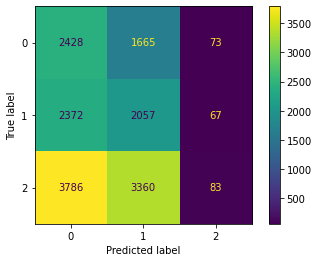

In [85]:
eval_model((text_model, image_model), test_loader)

In [90]:
LEARNING_RATE = 1e-4
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, image_model.parameters()), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, verbose=True, factor=0.5)
criterion = DistillationLoss(alpha=0.5)

In [ ]:
EPOCH = 1
image_model, min_val_loss = train_model((text_model, image_model), (train_loader, val_loader), EPOCH, criterion, optimizer, model_name='drive/MyDrive/Deep Project/weakly_sup', scheduler=scheduler)

In [132]:
torch.save(image_model.state_dict(), 'drive/MyDrive/Deep Project/weak_sup.pt')
torch.save(text_model.state_dict(), 'drive/MyDrive/Deep Project/bert_model_weak_sup.pt')

In [ ]:
eval_model((text_model, image_model), val_loader)

: Test Loss: 3.398e+01 - Accuracy: 50.82%:  58%|█████▊    | 155/265 [02:36<01:58,  1.07s/it]

: Test Loss: 3.401e+01 - Accuracy: 50.60%: 100%|██████████| 265/265 [04:52<00:00,  1.10s/it]

Accuracy of Test set: 0.5061355484236361


{'loss': 0.5671868580162289,
 'accuracy': 0.5061355484236361,
 'precision': 0.5014220982659482,
 'recall': 0.440136568412625,
 'f1': 0.43214981483206455}

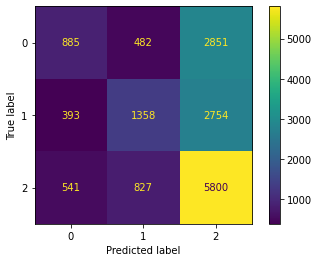

In [133]:
eval_model((text_model, image_model), test_loader)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd content/drive/MyDrive
torch.save(text_model.state_dict(), 'models/bert_model_weak_sup.pt')
torch.save(image_model.state_dict(), 'models/scene_model_weak_sup.pt')